<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB01 · El cuaderno, Colab y por qué la GPU acelera

**Fase 0 · Lección 2 — Probar el plato entero**

En el NB00 viste el mapa completo y comprobaste que el robot y el simulador funcionan en tu
Pi. Hoy resolvemos tres preguntas muy prácticas:

1. ¿Qué es exactamente esto que estás usando (un **notebook** y sus **celdas**)?
2. ¿Qué es **Google Colab** y por qué lo necesitaremos?
3. ¿Por qué una **GPU** (tarjeta gráfica) acelera tanto el entrenamiento? — y lo vas a
   **medir tú mismo** en tu Pi.

## 1 · El problema: entrenar es repetir la misma cuenta millones de veces

Recuerda el mapa: entrenar es repetir el bucle "observar → decidir → actuar → recompensa" y
ajustar la política. Ajustar la política son **operaciones con números** (sumas y
multiplicaciones dentro de la red neuronal), y hay que hacer **muchísimas**: millones, a
veces miles de millones.

Lo interesante es que casi todas esas cuentas son **iguales entre sí** y **no dependen unas
de otras**. Cuando tienes que hacer un montón de cuentas iguales e independientes, hay una
forma de ir muchísimo más rápido: hacerlas **todas a la vez** en lugar de una detrás de
otra. Esa es, en una frase, la razón de ser de la GPU. Vamos por partes.

## 2 · Qué es un notebook y qué es una celda

Esto que estás leyendo es un **notebook** (cuaderno). Es un documento que mezcla dos cosas:

- **Celdas de texto** (como esta): explicaciones, escritas en un formato sencillo llamado
  *markdown*.
- **Celdas de código**: trozos de Python que se **ejecutan** y muestran su resultado justo
  debajo.

```
   ┌─────────────────────────────────────────┐
   │ [texto]  "Vamos a sumar dos números"     │  ← celda de markdown
   ├─────────────────────────────────────────┤
   │ [código] a = 2 + 3                        │  ← celda de código
   │          print(a)                         │
   │ ─────────────────────────────────────    │
   │ 5                                         │  ← su resultado, debajo
   └─────────────────────────────────────────┘
```

Claves que hay que entender bien:

- **Se ejecutan una a una**, normalmente de arriba abajo, pulsando `Shift + Enter` en cada
  celda.
- **El estado se recuerda entre celdas.** Si en una celda escribes `a = 5`, en una celda de
  más abajo `a` sigue valiendo 5. Es como si todas las celdas compartieran la misma memoria.
- **Puedes reejecutar** una celda las veces que quieras. Ojo: si ejecutas las celdas en
  desorden, puedes liarte (una variable puede tener un valor de una ejecución anterior). La
  regla sana: cuando dudes, reinicia y ejecuta todo de arriba abajo.

Vamos a comprobar en vivo que el estado se recuerda:

In [1]:
# Celda A: definimos una variable
mensaje = "el estado se recuerda entre celdas"
numero = 40
print("Celda A ejecutada.")

Celda A ejecutada.


In [2]:
# Celda B: usamos lo definido en la celda A, sin volver a escribirlo
print(mensaje)
print("numero + 2 =", numero + 2)

el estado se recuerda entre celdas
numero + 2 = 42


La celda B ha podido usar `mensaje` y `numero` aunque se definieron en la celda A. Eso es el
"estado compartido". Es cómodo, pero recuerda la trampa: el orden en que ejecutas importa.

## 3 · Qué es Google Colab (y por qué lo necesitaremos)

Tu Pi y tu portátil no tienen una GPU potente. Para entrenar redes de verdad necesitaremos
una. La forma **gratuita** de conseguir una es **Google Colab**:

> **Colab** = notebooks (como este) que se ejecutan en **los ordenadores de Google**, y
> Google te presta una **GPU** gratis durante un rato.

Cómo se usa, paso a paso (lo harás de verdad en el NB02):

1. Vas a `colab.research.google.com` con tu cuenta de Google.
2. Abres un notebook (puede ser uno tuyo desde GitHub, o uno nuevo).
3. En el menú **Entorno de ejecución → Cambiar tipo de entorno de ejecución**, eliges
   **GPU**.
4. Ejecutas las celdas igual que aquí.

**Límites que conviene saber desde ya** (por eso trabajaremos con cuidado):

- La sesión **se corta** si la dejas inactiva o tras unas horas. Todo lo que esté solo en la
  memoria de Colab **se pierde**.
- **No siempre** te asigna GPU (en las horas de más demanda puede tocarte solo CPU).
- Por eso la regla de oro: **guarda siempre lo importante en tu Google Drive** (los modelos
  entrenados, los resultados), no solo en la memoria de la sesión.

La Pi y el portátil los usaremos para programar, para MuJoCo en CPU y para **ejecutar
políticas ya entrenadas**. Colab, para **entrenar**.

## 4 · CPU y GPU: el genio y el ejército de niños

Aquí está la idea que hay que meterse en la cabeza. Imagina dos formas de hacer cuentas:

- **La CPU es como unos pocos genios.** Cada uno resuelve cualquier problema, por difícil y
  enrevesado que sea, y toma decisiones complicadas. Pero son pocos (tu Pi tiene 4). Si les
  das un millón de sumas tontas, las hacen una detrás de otra: rápidos, pero en fila.

- **La GPU es como un ejército de miles de niños de primaria.** Cada niño solo sabe sumar y
  multiplicar, y no sabe tomar decisiones complicadas. Pero son **miles**, y trabajan **a la
  vez**. Si les repartes un millón de sumas tontas —una a cada niño—, las terminan casi
  todas al mismo tiempo.

```
   CPU (4 genios):   suma1 → suma2 → suma3 → ... → suma1000000   (en fila, rapidísimos)

   GPU (miles):      suma1  ┐
                     suma2  │  todas
                     suma3  ├─ a la vez
                     ...    │
                     suma1000000 ┘
```

Entrenar una red neuronal es **justo** el caso bueno para la GPU: son montañas de
multiplicaciones y sumas iguales e independientes. Por eso una GPU puede entrenar en horas lo
que a una CPU le llevaría semanas.

La palabra técnica para "hacer la misma operación sobre muchos datos a la vez" es
**vectorizar**. No necesitas una GPU para *ver* el efecto: tu propia CPU, cuando le pides las
cuentas en bloque (vectorizadas) en vez de una a una con un bucle, ya va muchísimo más
rápido, porque puede aprovechar mejor su circuitería. Vamos a **medirlo**.

## 5 · Míde­lo tú: bucle a mano vs. cuentas en bloque

Vamos a hacer la misma operación de dos formas y a cronometrarlas:

- **A mano, uno a uno:** un bucle `for` que recorre un millón de números y eleva cada uno al
  cuadrado, de Python puro.
- **En bloque (vectorizado):** le pedimos a NumPy que eleve al cuadrado **todo el array de
  golpe**.

Es el mismo resultado; solo cambia si las cuentas van en fila o en bloque. `NumPy` es la
biblioteca de cálculo numérico de Python: guarda los números en bloques compactos y opera
sobre todos a la vez, que es la versión "en pequeño" de lo que hace una GPU.

In [3]:
import numpy as np
import time

N = 1_000_000                       # un millón de números
datos = np.random.rand(N)           # N números al azar entre 0 y 1

# --- Forma A: a mano, uno a uno, con un bucle de Python puro ---
t0 = time.perf_counter()            # marca de tiempo antes
resultado_bucle = []
for x in datos:                     # recorre los N números uno a uno
    resultado_bucle.append(x * x)   # eleva al cuadrado y guarda
t1 = time.perf_counter()            # marca de tiempo después
tiempo_bucle = t1 - t0

# --- Forma B: en bloque, vectorizado, con NumPy ---
t0 = time.perf_counter()
resultado_vector = datos * datos    # eleva TODO el array al cuadrado de golpe
t1 = time.perf_counter()
tiempo_vector = t1 - t0

print(f"Bucle a mano (uno a uno): {tiempo_bucle*1000:8.1f} ms")
print(f"En bloque (vectorizado):  {tiempo_vector*1000:8.1f} ms")
print(f"El bloque fue ~{tiempo_bucle/tiempo_vector:.0f} veces más rápido.")

Bucle a mano (uno a uno):    199.6 ms
En bloque (vectorizado):       2.3 ms
El bloque fue ~87 veces más rápido.


Fíjate en el número final: hacer **exactamente la misma cuenta** en bloque, en vez de una a
una, es decenas o cientos de veces más rápido, **en la misma máquina**. Una GPU lleva esta
misma idea al extremo con miles de núcleos. Por eso entrenamos en GPU.

Veámoslo crecer con el tamaño del problema, en una gráfica:

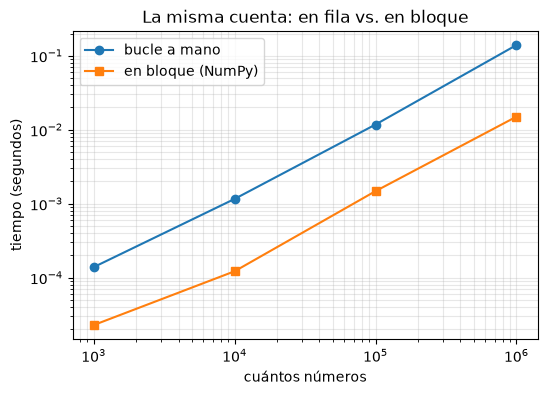

Cuantos más datos, más gana el cálculo en bloque.


In [4]:
import matplotlib.pyplot as plt

tamanos = [1_000, 10_000, 100_000, 1_000_000]
tiempos_bucle = []
tiempos_vector = []

for n in tamanos:
    d = np.random.rand(n)

    t0 = time.perf_counter()
    r = [x * x for x in d]          # bucle (aquí en forma compacta de lista)
    tiempos_bucle.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    r = d * d                       # vectorizado
    tiempos_vector.append(time.perf_counter() - t0)

plt.figure(figsize=(6, 4))
plt.loglog(tamanos, tiempos_bucle, "o-", label="bucle a mano")
plt.loglog(tamanos, tiempos_vector, "s-", label="en bloque (NumPy)")
plt.xlabel("cuántos números")
plt.ylabel("tiempo (segundos)")
plt.title("La misma cuenta: en fila vs. en bloque")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

print("Cuantos más datos, más gana el cálculo en bloque.")

## 6 · Lo que sale mal: "en bloque SIEMPRE es más rápido" (falso)

Es tentador concluir: "vale, entonces vectorizar/GPU siempre gana, usémoslo para todo". Y no
es verdad. Poner las cuentas en bloque (y más aún, mandarlas a una GPU) tiene un **coste
fijo de preparación**: hay que colocar los datos, arrancar el maquinaria, etc. Si el problema
es **diminuto**, ese coste fijo pesa más que lo que ahorras.

Vamos a verlo con un problema minúsculo: elevar al cuadrado **solo 5 números**.

In [5]:
# Problema diminuto: 5 números, repetido muchas veces para medir bien
d_pequeno = np.random.rand(5)
repeticiones = 100_000

t0 = time.perf_counter()
for _ in range(repeticiones):
    r = [x * x for x in d_pequeno]     # a mano
tiempo_mano = time.perf_counter() - t0

t0 = time.perf_counter()
for _ in range(repeticiones):
    r = d_pequeno * d_pequeno          # en bloque (NumPy)
tiempo_np = time.perf_counter() - t0

print(f"Con solo 5 números ({repeticiones} veces):")
print(f"  a mano:    {tiempo_mano*1000:7.1f} ms")
print(f"  en bloque: {tiempo_np*1000:7.1f} ms")
ganador = "en bloque" if tiempo_np < tiempo_mano else "a mano (!)"
print(f"  gana: {ganador}")
print()
print("Moraleja: el cálculo en bloque / la GPU brillan con MUCHOS datos.")
print("Para poquísimos datos, el coste de preparación puede no compensar.")

Con solo 5 números (100000 veces):
  a mano:      149.5 ms
  en bloque:    83.7 ms
  gana: en bloque

Moraleja: el cálculo en bloque / la GPU brillan con MUCHOS datos.
Para poquísimos datos, el coste de preparación puede no compensar.


En problemas diminutos, el bucle a mano puede empatar o incluso ganar, porque NumPy paga un
pequeño peaje fijo en cada llamada. La conclusión correcta no es "vectorizar siempre gana",
sino:

> El cálculo en bloque (y la GPU) ganan **cuando hay muchísimos datos iguales e
> independientes**. Entrenar redes es exactamente ese caso, por eso usamos GPU. Pero para
> una cuenta pequeña y suelta, a veces lo simple es lo mejor.

Esto también explica por qué **entrenar** va a Colab (millones de operaciones → GPU) pero
**ejecutar** una política ya entrenada corre de sobra en tu Pi (pocas operaciones por paso).

## 7 · Dónde vive esto en la ruta

- Entrenaremos en **Colab (GPU)** en las Fases 0, 2, 3 y 5.
- Programaremos y ejecutaremos políticas en **CPU** (Pi/portátil) en todas las fases.
- La idea de **vectorizar** volverá con fuerza en la Fase 1 (NumPy) y en la Fase 5, donde
  MuJoCo Playground simula **miles de robots a la vez** en una GPU — el mismo principio del
  "ejército de niños", pero con robots enteros.

## 8 · Preguntas de comprensión

**P1.** En un notebook, si en la celda 3 escribes `x = 10` y luego, más abajo, en la celda 7
usas `x`, ¿cuánto vale? ¿Por qué?

**P2.** Da **dos** motivos por los que conviene guardar los modelos entrenados en Google
Drive y no dejarlos solo en la memoria de la sesión de Colab.

**P3.** Con la analogía del genio y el ejército de niños, ¿por qué entrenar una red neuronal
es un trabajo "de ejército de niños" y no "de genio"?

**P4.** Mediste que el cálculo en bloque era mucho más rápido con un millón de números pero
apenas (o nada) con cinco. ¿Por qué?

**P5.** Tu Pi ejecuta bien una política ya entrenada pero no sirve para entrenar. Explica la
diferencia en términos de "cuántas operaciones".

<details>
<summary>▶ Solución P1</summary>

Vale **10**. En un notebook el estado (las variables) se comparte entre celdas y se recuerda
mientras el "kernel" (el motor que ejecuta el código) siga vivo. Salvedad importante: eso es
cierto si ejecutaste la celda 3 antes que la 7; si las ejecutas en desorden o reinicias el
kernel, el valor puede no ser el que esperas.
</details>

<details>
<summary>▶ Solución P2</summary>

(1) La sesión de Colab **se corta** por inactividad o tras unas horas, y todo lo que esté
solo en su memoria se pierde; en Drive persiste. (2) Un entrenamiento puede durar más que una
sola sesión, así que guardar en Drive te permite **retomar** desde donde ibas en otra sesión
(o en otro día) sin repetir el trabajo.
</details>

<details>
<summary>▶ Solución P3</summary>

Porque entrenar consiste en hacer **muchísimas** operaciones **sencillas** (sumas y
multiplicaciones dentro de la red) que además son **independientes** entre sí, así que se
pueden repartir y hacer a la vez. No requiere pocas decisiones muy complicadas (el genio),
sino un ejército repartiéndose cuentas tontas. Ese reparto masivo y simultáneo es lo que hace
bien una GPU.
</details>

<details>
<summary>▶ Solución P4</summary>

Porque poner las cuentas en bloque tiene un **coste fijo de preparación** por llamada. Con un
millón de números, ese coste fijo es insignificante frente a lo que ahorras al no ir uno a
uno, así que ganas muchísimo. Con cinco números, casi todo el tiempo es coste de preparación,
que hay que pagar igual, así que apenas notas mejora (o incluso pierdes).
</details>

<details>
<summary>▶ Solución P5</summary>

Entrenar exige repetir el bucle y ajustar la red **millones de veces**: son operaciones a
raudales, trabajo de GPU. Ejecutar una política ya entrenada solo requiere, en cada paso,
pasar la observación por la red **una vez** para obtener la acción: son poquísimas
operaciones por paso, que una CPU modesta como la de la Pi hace de sobra en tiempo real.
</details>

## 9 · Posdata

Si te has perdido, dime el apartado y la frase exacta y lo reescribo.

En el **NB02** montarás **el plato entero de verdad**: abrirás un notebook en Colab con GPU y
entrenarás un humanoide de MuJoCo hasta que empiece a andar, y guardarás el resultado. Aquí
en la Pi prepararemos antes lo que se pueda para que llegues a Colab con las ideas claras.

---

## Apéndice · El Python de este notebook, desde cero

### A) `time.perf_counter()` — cronómetro
Devuelve un número de segundos de un reloj de alta precisión. No dice "la hora", solo sirve
para **restar** dos lecturas y saber cuánto pasó:
```python
t0 = time.perf_counter()
... # lo que quieres medir
transcurrido = time.perf_counter() - t0
```

### B) `1_000_000` — guiones bajos en los números
En Python puedes escribir `1_000_000` en vez de `1000000`. Los guiones bajos se ignoran; solo
sirven para leerlo mejor (como los puntos de mil). Vale un millón.

### C) NumPy: arrays y operaciones "en bloque"
- `np.random.rand(N)` crea un **array** de N números al azar entre 0 y 1. Un array es como
  una lista, pero guardada de forma compacta y pensada para el cálculo rápido.
- `datos * datos` multiplica **elemento a elemento**: el primero por el primero, el segundo
  por el segundo… todo de golpe. Eso es "vectorizar".

### D) Comprensión de lista `[x*x for x in d]`
Es una forma compacta de escribir un bucle que construye una lista:
```python
r = [x*x for x in d]      # equivale a:  r=[]; for x in d: r.append(x*x)
```
Se lee "x al cuadrado, para cada x en d".

### E) `for _ in range(repeticiones):`
El guion bajo `_` es un nombre de variable que usamos cuando **no nos importa** su valor;
aquí solo queremos repetir el bloque muchas veces, no usar el número.

### F) Formato de números en f-strings
```python
print(f"{tiempo*1000:8.1f} ms")
```
Dentro de las llaves, tras los dos puntos, `8.1f` significa: número decimal (`f`) con 1
decimal, ocupando al menos 8 caracteres (para que las columnas queden alineadas).

### G) matplotlib: `loglog`, `legend`, `grid`
- `plt.loglog(x, y, "o-")` dibuja una línea con puntos, pero con **los dos ejes en escala
  logarítmica** (cada marca multiplica por 10). Se usa cuando los valores abarcan rangos
  enormes, como aquí (de mil a un millón). El `"o-"` / `"s-"` elige el símbolo (círculo,
  cuadrado) y la línea.
- `plt.legend()` muestra la leyenda (qué línea es cuál), usando las etiquetas `label=...`.
- `plt.grid(True, which="both", alpha=0.3)` dibuja una rejilla tenue de fondo.

### H) Operador ternario
```python
ganador = "en bloque" if tiempo_np < tiempo_mano else "a mano"
```
Se lee de un tirón: *"en bloque" si el tiempo de NumPy es menor, y si no, "a mano"*. Es una
forma corta de un `if/else` que elige entre dos valores.